=== Dataset Loan Approval ===
Total samples: 179

First 5 rows:
   age  income  credit_score  employment_years  num_accounts  loan_amount  \
0   31  129751           649                36             8       434671   
1   39  137845           316                38             2        47078   
2   70  125878           815                20             6        84767   
3   20  185838           776                30             3       398293   
4   31   76250           546                23             6       136994   

   debt_to_income  payment_history  actual_approval  predicted_approval  
0            0.40               13                0                   1  
1            0.20               93                1                   1  
2            0.52               38                1                   1  
3            0.54               46                1                   0  
4            0.11               81                0                   0  

Dataset Info:
<class 'pandas

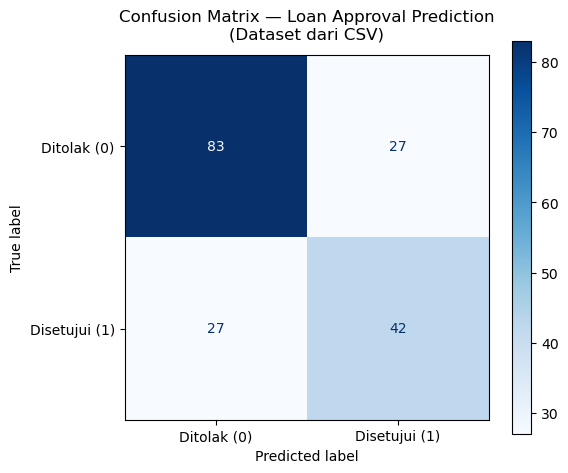

✅ Gambar disimpan: confusion_matrix.png

=== Nilai Confusion Matrix ===
TP (True Positive)   = 42
TN (True Negative)   = 83
FP (False Positive)  = 27
FN (False Negative)  = 27

=== Metrik Evaluasi ===
Total Data: 179
TP=42, TN=83, FP=27, FN=27

Akurasi  = (TP + TN) / Total
         = (42 + 83) / 179
         = 125 / 179
         = 0.6983  →  69.83%

Presisi  = TP / (TP + FP)
         = 42 / (42 + 27)
         = 42 / 69
         = 0.6087  →  60.87%

Recall   = TP / (TP + FN)
         = 42 / (42 + 27)
         = 42 / 69
         = 0.6087  →  60.87%

F1-Score = 0.6087  →  60.87%


In [4]:
# ============================================================
# TITANIC SURVIVAL PREDICTION - CONFUSION MATRIX
# Data: Loan Approval Dataset (Load from CSV)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ============================================================
# LOAD DATA DARI CSV - SOAL 4: CONFUSION MATRIX
# ============================================================
df = pd.read_csv('confusion_matrix_data.csv')

print("=== Dataset Loan Approval ===")
print(f"Total samples: {len(df)}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nDataset Info:")
print(df.info())
print(f"\nDistribusi Approval: {df['actual_approval'].value_counts().to_dict()}")

# Extract features dan target
X = df.drop(['actual_approval', 'predicted_approval'], axis=1)
y_actual = df['actual_approval']
y_predicted = df['predicted_approval']

print("\n" + "="*60)
print("SOAL 4: CONFUSION MATRIX DARI DATASET")
print("="*60)

# ============================================================
# CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_actual, y_predicted)

print("\n=== Confusion Matrix ===")
print(pd.DataFrame(cm,
    index   = ["Actual: Ditolak (0)", "Actual: Disetujui (1)"],
    columns = ["Pred: Ditolak (0)",   "Pred: Disetujui (1)"]
))

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ["Ditolak (0)", "Disetujui (1)"]
)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title("Confusion Matrix — Loan Approval Prediction\n(Dataset dari CSV)", pad=12)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Gambar disimpan: confusion_matrix.png")

# ============================================================
# EKSTRAK NILAI TP, TN, FP, FN
# ============================================================
tn, fp, fn, tp = cm.ravel()

print("\n=== Nilai Confusion Matrix ===")
print(f"TP (True Positive)   = {tp}")
print(f"TN (True Negative)   = {tn}")
print(f"FP (False Positive)  = {fp}")
print(f"FN (False Negative)  = {fn}")

# ============================================================
# HITUNG AKURASI, PRESISI, DAN RECALL
# ============================================================
total    = tp + tn + fp + fn
akurasi  = (tp + tn) / total
presisi  = tp / (tp + fp)
recall   = tp / (tp + fn)
f1_score = 2 * (presisi * recall) / (presisi + recall)

print("\n=== Metrik Evaluasi ===")
print(f"Total Data: {total}")
print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")
print(f"\nAkurasi  = (TP + TN) / Total")
print(f"         = ({tp} + {tn}) / {total}")
print(f"         = {tp+tn} / {total}")
print(f"         = {akurasi:.4f}  →  {akurasi*100:.2f}%")

print(f"\nPresisi  = TP / (TP + FP)")
print(f"         = {tp} / ({tp} + {fp})")
print(f"         = {tp} / {tp+fp}")
print(f"         = {presisi:.4f}  →  {presisi*100:.2f}%")

print(f"\nRecall   = TP / (TP + FN)")
print(f"         = {tp} / ({tp} + {fn})")
print(f"         = {tp} / {tp+fn}")
print(f"         = {recall:.4f}  →  {recall*100:.2f}%")

print(f"\nF1-Score = {f1_score:.4f}  →  {f1_score*100:.2f}%")


SOAL 5: ROOT MEAN SQUARED ERROR (RMSE)

=== Dataset Fare Prediction ===
Total samples: 4

Data:
 actual_fare  predicted_fare
          50              45
          10              25
         100             100
         500             400

=== Perhitungan Error ===
Data         Aktual     Prediksi    Selisih   Selisih²
----------------------------------------------------
Data 1       50.00        45.00       5.00      25.00
Data 2       10.00        25.00     -15.00     225.00
Data 3      100.00       100.00       0.00       0.00
Data 4      500.00       400.00     100.00   10000.00
----------------------------------------------------
Jumlah (Σ)                                      10250.00

=== Perhitungan RMSE ===

Rumus RMSE:
RMSE = √(Σ(y_aktual - y_prediksi)² / n)

Perhitungan:
RMSE = √(10250.00 / 4)
     = √(2562.50)
     = 50.6211

=== Hasil Akhir ===
MSE  = 2562.50
RMSE = 50.6211

→ Rata-rata error prediksi harga tiket: ±50.62


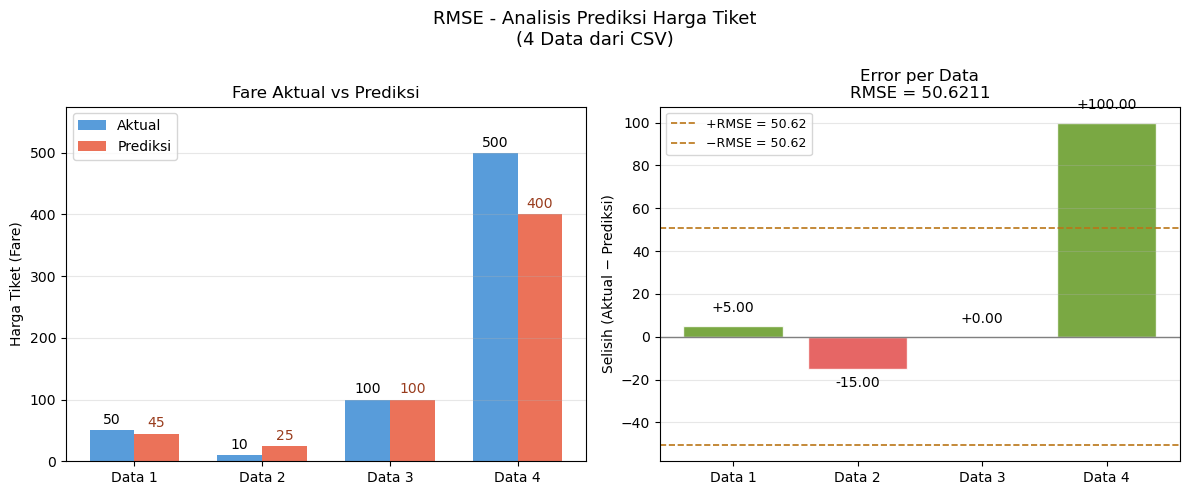


✅ Gambar disimpan: rmse_analysis.png

       RINGKASAN HASIL RMSE
  Jumlah data                             4
  Jumlah Σ(selisih²)               10250.00
  Mean Squared Error (MSE)          2562.50
  Root Mean Squared Error (RMSE)         50.6211


In [9]:
# ============================================================
# SOAL 5: ROOT MEAN SQUARED ERROR (RMSE)
# Data: 4 Data Fare Prediction (Load from CSV)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# ============================================================
# LOAD DATA DARI CSV - SOAL 5: RMSE
# ============================================================
df = pd.read_csv('rmse_data.csv')

print("\n" + "="*60)
print("SOAL 5: ROOT MEAN SQUARED ERROR (RMSE)")
print("="*60)
print("\n=== Dataset Fare Prediction ===")
print(f"Total samples: {len(df)}")
print(f"\nData:")
print(df.to_string(index=False))

# Extract actual dan predicted fare
y_actual = df['actual_fare'].values
y_predicted = df['predicted_fare'].values

# ============================================================
# HITUNG SELISIH (ERROR) UNTUK SETIAP DATA
# ============================================================
df['selisih'] = df['actual_fare'] - df['predicted_fare']
df['selisih²'] = df['selisih'] ** 2

print("\n=== Perhitungan Error ===")
print(f"{'Data':<8} {'Aktual':>10} {'Prediksi':>12} {'Selisih':>10} {'Selisih²':>10}")
print("-" * 52)
for idx, row in df.iterrows():
    print(f"Data {idx+1:<2} {row['actual_fare']:>10.2f} {row['predicted_fare']:>12.2f} "
          f"{row['selisih']:>10.2f} {row['selisih²']:>10.2f}")
print("-" * 52)

# ============================================================
# HITUNG MSE DAN RMSE
# ============================================================
n = len(df)
sum_sq = df['selisih²'].sum()
mse = sum_sq / n
rmse = np.sqrt(mse)

print(f"{'Jumlah (Σ)':<8} {'':>10} {'':>12} {'':>10} {sum_sq:>10.2f}")

print("\n=== Perhitungan RMSE ===")
print(f"\nRumus RMSE:")
print(f"RMSE = √(Σ(y_aktual - y_prediksi)² / n)")
print(f"\nPerhitungan:")
print(f"RMSE = √({sum_sq:.2f} / {n})")
print(f"     = √({mse:.2f})")
print(f"     = {rmse:.4f}")

print(f"\n=== Hasil Akhir ===")
print(f"MSE  = {mse:.2f}")
print(f"RMSE = {rmse:.4f}")
print(f"\n→ Rata-rata error prediksi harga tiket: ±{rmse:.2f}")

# ============================================================
# VISUALISASI AKTUAL VS PREDIKSI
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("RMSE - Analisis Prediksi Harga Tiket\n(4 Data dari CSV)",
             fontsize=13)

data_labels = [f"Data {i+1}" for i in range(n)]
x_pos = np.arange(n)
width = 0.35

# --- Plot 1: Aktual vs Prediksi ---
ax1 = axes[0]
bars1 = ax1.bar(x_pos - width/2, df['actual_fare'],     width, label='Aktual',   color='#3B8BD4', alpha=0.85)
bars2 = ax1.bar(x_pos + width/2, df['predicted_fare'],  width, label='Prediksi', color='#E8593C', alpha=0.85)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=10, color='#993C1D')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(data_labels)
ax1.set_ylabel("Harga Tiket (Fare)")
ax1.set_title("Fare Aktual vs Prediksi")
ax1.legend()
ax1.set_ylim(0, max(df['actual_fare'].max(), df['predicted_fare'].max()) * 1.15)
ax1.grid(axis='y', alpha=0.3)

# --- Plot 2: Error per Data ---
ax2 = axes[1]
colors_err = ['#E24B4A' if s < 0 else '#639922' for s in df['selisih']]
bars3 = ax2.bar(x_pos, df['selisih'], color=colors_err, alpha=0.85, edgecolor='white')

for bar, val in zip(bars3, df['selisih']):
    offset = 5 if val >= 0 else -10
    ax2.text(bar.get_x() + bar.get_width()/2, val + offset,
             f'{val:+.2f}', ha='center', va='bottom', fontsize=10)

ax2.axhline(0,    color='gray',    linewidth=1,   linestyle='-')
ax2.axhline(rmse, color='#BA7517', linewidth=1.2, linestyle='--', label=f'+RMSE = {rmse:.2f}')
ax2.axhline(-rmse, color='#BA7517', linewidth=1.2, linestyle='--', label=f'−RMSE = {rmse:.2f}')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(data_labels)
ax2.set_ylabel("Selisih (Aktual − Prediksi)")
ax2.set_title(f"Error per Data\nRMSE = {rmse:.4f}")
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("rmse_analysis.png", dpi=150)
plt.show()
print("\n✅ Gambar disimpan: rmse_analysis.png")

# ============================================================
# RINGKASAN AKHIR
# ============================================================
print("\n" + "="*50)
print("       RINGKASAN HASIL RMSE")
print("="*50)
print(f"  {'Jumlah data':<25} {n:>15}")
print(f"  {'Jumlah Σ(selisih²)':<25} {sum_sq:>15.2f}")
print(f"  {'Mean Squared Error (MSE)':<25} {mse:>15.2f}")
print(f"  {'Root Mean Squared Error (RMSE)':<25} {rmse:>15.4f}")
print("="*50)
